# Graph Attention Networks: Transductive + Inductive Experiments

This notebook runs:

- **Transductive node classification:** Cora, CiteSeer, PubMed
- **Inductive node classification:** PPI
- **Charts:** validation curves and final result comparison

Paper reference: Veličković et al., *Graph Attention Networks*, arXiv:1710.10903.

> Runtime recommendation: `Runtime > Change runtime type > T4 GPU` or better.


## Experiment 1: Standard GAT (Original `layers.py`)

Paper architecture: 8 heads × 8 features for transductive tasks, 3-layer SpGAT for PPI. Uses the original `layers.py` and `gat.py` / `sp_gat.py`.

In [ ]:
# ============================================================
# 1. Install dependencies
# ============================================================
# Run this once after opening the notebook in Colab.

import sys
import subprocess

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'torch-geometric', 'scikit-learn'])
else:
    print('Not running in Colab. Make sure torch_geometric and scikit-learn are installed.')


In [ ]:
# ============================================================
# 2. User-editable Drive path
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

PROJECT_DIR = '/content/drive/MyDrive/CS4782/Final Project/CS4782FinalProjectGraphAttention'

import os
from pathlib import Path

PROJECT_DIR = Path(PROJECT_DIR)
print('PROJECT_DIR =', PROJECT_DIR)
print('Exists:', PROJECT_DIR.exists())
print('Contents:')
if PROJECT_DIR.exists():
    for p in sorted(PROJECT_DIR.iterdir()):
        print(' -', p.name)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PROJECT_DIR = /content/drive/MyDrive/CS4782/Final Project/CS4782FinalProjectGraphAttention
Exists: True
Contents:
 - .git
 - .gitignore
 - CS4782_GAT_Paper_Reimplementation.ipynb
 - GCN.py
 - MLP.py
 - README.md
 - data
 - data_preprocessing.py
 - gat_browser_only_drive_mount_colab_sparse_fix.ipynb
 - models
 - test.py
 - utils


In [ ]:
# ============================================================
# 3. Import your existing code from Drive
# ============================================================

import os
import sys
import shutil
from pathlib import Path

PROJECT_DIR = Path(PROJECT_DIR)
assert PROJECT_DIR.exists(), f'PROJECT_DIR does not exist: {PROJECT_DIR}'

RUNTIME_IMPORT_ROOT = Path('/content/gat_runtime_imports')
RUNTIME_IMPORT_ROOT.mkdir(exist_ok=True)

models_src = None
if (PROJECT_DIR / 'models').exists():
    models_src = PROJECT_DIR / 'models'
else:
    raise FileNotFoundError('Could not find either models/ or model/ inside PROJECT_DIR')

utils_src = PROJECT_DIR / 'utils'
if not utils_src.exists():
    raise FileNotFoundError('Could not find utils/ inside PROJECT_DIR')

for link_name, src in [('models', models_src), ('utils', utils_src)]:
    dst = RUNTIME_IMPORT_ROOT / link_name
    if dst.exists() or dst.is_symlink():
        if dst.is_symlink() or dst.is_file():
            dst.unlink()
        else:
            shutil.rmtree(dst)
    os.symlink(src, dst)

# Add project root and runtime import root to sys.paths
for p in [str(RUNTIME_IMPORT_ROOT), str(PROJECT_DIR)]:
    if p not in sys.path:
        sys.path.insert(0, p)

from models.gat import GAT
from models.sp_gat import SpGAT
from models.base_gattn import BaseGAttN
from utils.layers import AttentionHead, SpAttentionHead

print('Imported GAT from:', GAT)
print('Imported SpGAT from:', SpGAT)
print('Runtime package root:', RUNTIME_IMPORT_ROOT)


Imported GAT from: <class 'models.gat.GAT'>
Imported SpGAT from: <class 'models.sp_gat.SpGAT'>
Runtime package root: /content/gat_runtime_imports


In [ ]:
# ============================================================
# 4. Imports, device, reproducibility, memory cleanup
# ============================================================

import gc
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F
from torch_geometric.datasets import Planetoid, PPI
from torch_geometric.utils import add_self_loops
from torch_geometric.loader import DataLoader
from sklearn.metrics import f1_score

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device =', device)
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

os.environ.setdefault('PYTORCH_CUDA_ALLOC_CONF', 'expandable_segments:True')

def cleanup_cuda():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()


device = cuda
Tesla T4


## 6. Configuration

The transductive settings follow the common GAT paper-style setup: 8 hidden attention heads with 8 features each, dropout 0.6, ELU hidden activations, and masked cross entropy on train/validation/test masks.

For PPI, the full paper-style architecture is:

- 3 total GAT layers
- First two layers: 4 attention heads, 256 features per head
- Final layer: 6 attention heads averaged into multilabel logits
- BCE-with-logits loss and micro-F1 evaluation

The paper reports about **0.973 micro-F1** for PPI. Reproducing this exactly can vary by implementation, seed, GPU, sparse vs dense implementation, and early stopping behavior.


In [ ]:
# ============================================================
# 5. Experiment config
# ============================================================

DATA_ROOT = PROJECT_DIR / 'data'
if not DATA_ROOT.exists():
    DATA_ROOT = Path('/content/data')
print('DATA_ROOT =', DATA_ROOT)

RUN_TRANSDUCTIVE_DATASETS = ['Cora', 'CiteSeer', 'PubMed']
RUN_PPI = True

TRANSDUCTIVE_EPOCHS = 1000
TRANSDUCTIVE_PATIENCE = 100

PPI_EPOCHS = 1000
PPI_PATIENCE = 100

# If True, runs the paper-scale PPI architecture. If Colab OOMs, set to False for a smoke test.
FULL_PAPER_PPI = True

TRANSDUCTIVE_CONFIGS = {
    'Cora': dict(hid_units=[8], n_heads=[8, 1], attn_drop=0.6, ffd_drop=0.6, lr=0.005, weight_decay=5e-4, residual=False, use_sparse=False),
    'CiteSeer': dict(hid_units=[8], n_heads=[8, 1], attn_drop=0.6, ffd_drop=0.6, lr=0.005, weight_decay=5e-4, residual=False, use_sparse=False),
    'PubMed': dict(hid_units=[8], n_heads=[8, 1], attn_drop=0.6, ffd_drop=0.6, lr=0.005, weight_decay=1e-3, residual=False, use_sparse=True),
}

PPI_FULL_CONFIG = dict(
    # 2 hidden layers + 1 output layer = 3 total GAT layers.
    hid_units=[256, 256],
    n_heads=[4, 4, 6],
    attn_drop=0.0,
    ffd_drop=0.0,
    lr=0.005,
    weight_decay=0.0,
    residual=True,
    use_sparse=True,
    batch_size=1,
)

PPI_SMOKE_CONFIG = dict(
    hid_units=[16],
    n_heads=[4, 1],
    attn_drop=0.2,
    ffd_drop=0.2,
    lr=0.005,
    weight_decay=0.0,
    residual=True,
    use_sparse=True,
    batch_size=1,
)

PPI_CONFIG = PPI_FULL_CONFIG if FULL_PAPER_PPI else PPI_SMOKE_CONFIG


DATA_ROOT = /content/drive/MyDrive/CS4782/Final Project/CS4782FinalProjectGraphAttention/data


In [ ]:
# ============================================================
# 6. Graph helpers
# ============================================================

def preprocess_features(x):
    rowsum = x.sum(dim=1, keepdim=True).clamp(min=1e-9)
    return x / rowsum


def load_planetoid_dataset(name):
    dataset = Planetoid(root=str(DATA_ROOT), name=name)
    data = dataset[0]
    data.edge_index, _ = add_self_loops(data.edge_index, num_nodes=data.num_nodes)
    data.x = preprocess_features(data.x)
    return dataset, data


def edge_index_to_bias(edge_index, num_nodes, device):
    bias = torch.full((1, num_nodes, num_nodes), -1e9, device=device)
    edge_index = edge_index.to(device)
    bias[0, edge_index[0], edge_index[1]] = 0.0
    return bias


def edge_index_to_sparse_adj(edge_index, num_nodes, device):
    edge_index = edge_index.to(device)
    values = torch.ones(edge_index.shape[1], device=device)
    return torch.sparse_coo_tensor(edge_index, values, (num_nodes, num_nodes), device=device).coalesce()


def accuracy_from_logits(logits, y):
    return (logits.argmax(dim=-1) == y).float().mean().item()


def make_transductive_model(dataset, data, cfg):
    if cfg['use_sparse']:
        return SpGAT(
            in_features=dataset.num_features,
            nb_classes=dataset.num_classes,
            nb_nodes=data.num_nodes,
            hid_units=cfg['hid_units'],
            n_heads=cfg['n_heads'],
            attn_drop=cfg['attn_drop'],
            ffd_drop=cfg['ffd_drop'],
            residual=cfg['residual'],
        ).to(device)
    return GAT(
        in_features=dataset.num_features,
        nb_classes=dataset.num_classes,
        hid_units=cfg['hid_units'],
        n_heads=cfg['n_heads'],
        attn_drop=cfg['attn_drop'],
        ffd_drop=cfg['ffd_drop'],
        residual=cfg['residual'],
    ).to(device)


In [ ]:
# ============================================================
# 7. Train/evaluate transductive datasets
# ============================================================

def forward_transductive(model, data, cfg):
    x = data.x.to(device).unsqueeze(0)
    if cfg['use_sparse']:
        adj = edge_index_to_sparse_adj(data.edge_index, data.num_nodes, device)
        return model(x, adj).squeeze(0)
    bias = edge_index_to_bias(data.edge_index, data.num_nodes, device)
    return model(x, bias).squeeze(0)


def evaluate_transductive(model, data, cfg, mask):
    model.eval()
    with torch.no_grad():
        logits = forward_transductive(model, data, cfg)
        y = data.y.to(device)
        mask = mask.to(device)
        loss = F.cross_entropy(logits[mask], y[mask]).item()
        acc = accuracy_from_logits(logits[mask], y[mask])
    return loss, acc


def train_transductive_dataset(dataset_name):
    cleanup_cuda()
    dataset, data = load_planetoid_dataset(dataset_name)
    cfg = TRANSDUCTIVE_CONFIGS[dataset_name]
    model = make_transductive_model(dataset, data, cfg)
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg['lr'], weight_decay=cfg['weight_decay'])

    y = data.y.to(device)
    train_mask = data.train_mask.to(device)

    best_val_acc = -1.0
    best_state = None
    patience = 0
    history = []

    for epoch in range(1, TRANSDUCTIVE_EPOCHS + 1):
        model.train()
        optimizer.zero_grad()
        logits = forward_transductive(model, data, cfg)
        loss = F.cross_entropy(logits[train_mask], y[train_mask])
        loss.backward()
        optimizer.step()

        train_loss, train_acc = evaluate_transductive(model, data, cfg, data.train_mask)
        val_loss, val_acc = evaluate_transductive(model, data, cfg, data.val_mask)
        test_loss, test_acc = evaluate_transductive(model, data, cfg, data.test_mask)

        history.append(dict(
            dataset=dataset_name,
            epoch=epoch,
            train_loss=train_loss,
            train_acc=train_acc,
            val_loss=val_loss,
            val_acc=val_acc,
            test_loss=test_loss,
            test_acc=test_acc,
        ))

        if epoch == 1 or epoch % 25 == 0:
            print(f'{dataset_name:8s} | epoch {epoch:04d} | loss {train_loss:.4f} | val_acc {val_acc:.4f} | test_acc {test_acc:.4f}')

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience = 0
        else:
            patience += 1

        if patience >= TRANSDUCTIVE_PATIENCE:
            print(f'{dataset_name}: early stopping at epoch {epoch}')
            break

    if best_state is not None:
        model.load_state_dict({k: v.to(device) for k, v in best_state.items()})

    final_train_loss, final_train_acc = evaluate_transductive(model, data, cfg, data.train_mask)
    final_val_loss, final_val_acc = evaluate_transductive(model, data, cfg, data.val_mask)
    final_test_loss, final_test_acc = evaluate_transductive(model, data, cfg, data.test_mask)

    print(f'FINAL {dataset_name}: val_acc={final_val_acc:.4f}, test_acc={final_test_acc:.4f}')
    cleanup_cuda()
    return model, pd.DataFrame(history), dict(dataset=dataset_name, val_acc=final_val_acc, test_acc=final_test_acc)


In [ ]:
# ============================================================
# 8. Run transductive experiments
# ============================================================

transductive_histories = []
transductive_results = []

for dataset_name in RUN_TRANSDUCTIVE_DATASETS:
    model, hist, result = train_transductive_dataset(dataset_name)
    transductive_histories.append(hist)
    transductive_results.append(result)
    del model
    cleanup_cuda()

transductive_history_df = pd.concat(transductive_histories, ignore_index=True)
transductive_results_df = pd.DataFrame(transductive_results)
transductive_results_df


Cora     | epoch 0001 | loss 1.9448 | val_acc 0.2360 | test_acc 0.2000
Cora     | epoch 0025 | loss 1.8958 | val_acc 0.5600 | test_acc 0.5370
Cora     | epoch 0050 | loss 1.7729 | val_acc 0.6380 | test_acc 0.6460
Cora     | epoch 0075 | loss 1.5751 | val_acc 0.7360 | test_acc 0.7520
Cora     | epoch 0100 | loss 1.3543 | val_acc 0.7740 | test_acc 0.7800
Cora     | epoch 0125 | loss 1.1820 | val_acc 0.7840 | test_acc 0.7940
Cora     | epoch 0150 | loss 1.0540 | val_acc 0.7980 | test_acc 0.8010
Cora     | epoch 0175 | loss 0.9654 | val_acc 0.7920 | test_acc 0.8040
Cora     | epoch 0200 | loss 0.9048 | val_acc 0.8000 | test_acc 0.8100
Cora: early stopping at epoch 207
FINAL Cora: val_acc=0.8140, test_acc=0.8200
CiteSeer | epoch 0001 | loss 1.7911 | val_acc 0.2500 | test_acc 0.2420
CiteSeer | epoch 0025 | loss 1.7634 | val_acc 0.5820 | test_acc 0.5990
CiteSeer | epoch 0050 | loss 1.6988 | val_acc 0.6440 | test_acc 0.6510
CiteSeer | epoch 0075 | loss 1.5818 | val_acc 0.6680 | test_acc 0.6660

,dataset,val_acc,test_acc
0,Cora,0.814,0.820
1,CiteSeer,0.738,0.718
2,PubMed,0.816,0.777


In [28]:
# ============================================================
# 9. PPI helpers: full paper-style inductive training
# ============================================================

def make_ppi_model(sample, cfg):
    nb_classes = sample.y.shape[-1]
    if cfg['use_sparse']:
        return SpGAT(
            in_features=sample.num_node_features,
            nb_classes=nb_classes,
            nb_nodes=sample.num_nodes,
            hid_units=cfg['hid_units'],
            n_heads=cfg['n_heads'],
            attn_drop=cfg['attn_drop'],
            ffd_drop=cfg['ffd_drop'],
            residual=cfg['residual'],
        ).to(device)
    return GAT(
        in_features=sample.num_node_features,
        nb_classes=nb_classes,
        hid_units=cfg['hid_units'],
        n_heads=cfg['n_heads'],
        attn_drop=cfg['attn_drop'],
        ffd_drop=cfg['ffd_drop'],
        residual=cfg['residual'],
    ).to(device)


def forward_ppi(model, batch, cfg):
    batch = batch.to(device)
    x = batch.x.unsqueeze(0)
    N = batch.num_nodes
    if cfg['use_sparse']:
        model.nb_nodes = N
        adj = edge_index_to_sparse_adj(batch.edge_index, N, device)
        return model(x, adj).squeeze(0)
    bias = edge_index_to_bias(batch.edge_index, N, device)
    return model(x, bias).squeeze(0)


def ppi_micro_f1_from_logits(logits_list, labels_list):
    logits = torch.cat(logits_list, dim=0)
    labels = torch.cat(labels_list, dim=0)
    preds = (torch.sigmoid(logits) > 0.5).int().cpu().numpy()
    gold = labels.int().cpu().numpy()
    return f1_score(gold, preds, average='micro')


def evaluate_ppi(model, loader, cfg):
    model.eval()
    losses = []
    logits_list = []
    labels_list = []
    criterion = torch.nn.BCEWithLogitsLoss()

    with torch.no_grad():
        for batch in loader:
            logits = forward_ppi(model, batch, cfg)
            labels = batch.y.to(device).float()
            loss = criterion(logits, labels)
            losses.append(loss.item())
            logits_list.append(logits.detach().cpu())
            labels_list.append(labels.detach().cpu())

    return float(np.mean(losses)), ppi_micro_f1_from_logits(logits_list, labels_list)


def train_ppi_fullpaper():
    cleanup_cuda()
    ppi_train = PPI(root=str(DATA_ROOT / 'PPI'), split='train')
    ppi_val = PPI(root=str(DATA_ROOT / 'PPI'), split='val')
    ppi_test = PPI(root=str(DATA_ROOT / 'PPI'), split='test')

    cfg = PPI_CONFIG
    train_loader = DataLoader(ppi_train, batch_size=cfg['batch_size'], shuffle=True)
    val_loader = DataLoader(ppi_val, batch_size=1, shuffle=False)
    test_loader = DataLoader(ppi_test, batch_size=1, shuffle=False)

    model = make_ppi_model(ppi_train[0], cfg)
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg['lr'], weight_decay=cfg['weight_decay'])
    criterion = torch.nn.BCEWithLogitsLoss()

    best_val_f1 = -1.0
    best_state = None
    patience = 0
    history = []

    for epoch in range(1, PPI_EPOCHS + 1):
        model.train()
        batch_losses = []

        for batch in train_loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            logits = forward_ppi(model, batch, cfg)
            loss = criterion(logits, batch.y.float())
            loss.backward()
            optimizer.step()
            batch_losses.append(loss.item())

        train_loss = float(np.mean(batch_losses))
        val_loss, val_f1 = evaluate_ppi(model, val_loader, cfg)

        history.append(dict(epoch=epoch, train_loss=train_loss, val_loss=val_loss, val_micro_f1=val_f1))

        if epoch == 1 or epoch % 10 == 0:
            print(f'PPI | epoch {epoch:04d} | train_loss {train_loss:.4f} | val_f1 {val_f1:.4f}')

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience = 0
        else:
            patience += 1

        if patience >= PPI_PATIENCE:
            print(f'PPI: early stopping at epoch {epoch}')
            break

    if best_state is not None:
        model.load_state_dict({k: v.to(device) for k, v in best_state.items()})

    test_loss, test_f1 = evaluate_ppi(model, test_loader, cfg)
    print(f'FINAL PPI: val_micro_f1={best_val_f1:.4f}, test_micro_f1={test_f1:.4f}')

    cleanup_cuda()
    return model, pd.DataFrame(history), dict(dataset='PPI', val_micro_f1=best_val_f1, test_micro_f1=test_f1)


In [29]:
# ============================================================
# 10. Run PPI inductive experiment
# ============================================================

if RUN_PPI:
    ppi_model, ppi_history_df, ppi_result = train_ppi_fullpaper()
    display(pd.DataFrame([ppi_result]))
else:
    ppi_history_df = pd.DataFrame()
    ppi_result = None


PPI | epoch 0001 | train_loss 0.6200 | val_f1 0.4760
PPI | epoch 0010 | train_loss 0.4269 | val_f1 0.6293
PPI | epoch 0020 | train_loss 0.3135 | val_f1 0.7289
PPI | epoch 0030 | train_loss 0.2567 | val_f1 0.7797
PPI | epoch 0040 | train_loss 0.2144 | val_f1 0.8040
PPI | epoch 0050 | train_loss 0.1762 | val_f1 0.8421
PPI | epoch 0060 | train_loss 0.1525 | val_f1 0.8526
PPI | epoch 0070 | train_loss 0.1668 | val_f1 0.8036
PPI | epoch 0080 | train_loss 0.1176 | val_f1 0.8880
PPI | epoch 0090 | train_loss 0.1081 | val_f1 0.8865
PPI | epoch 0100 | train_loss 0.0910 | val_f1 0.8941
PPI | epoch 0110 | train_loss 0.1076 | val_f1 0.8938
PPI | epoch 0120 | train_loss 0.0961 | val_f1 0.8927
PPI | epoch 0130 | train_loss 0.0529 | val_f1 0.9175
PPI | epoch 0140 | train_loss 0.0642 | val_f1 0.9198
PPI | epoch 0150 | train_loss 0.0979 | val_f1 0.8782
PPI | epoch 0160 | train_loss 0.0759 | val_f1 0.8947
PPI | epoch 0170 | train_loss 0.0371 | val_f1 0.9351
PPI | epoch 0180 | train_loss 0.1530 | val_f1 

,dataset,val_micro_f1,test_micro_f1
0,PPI,0.952433,0.969972


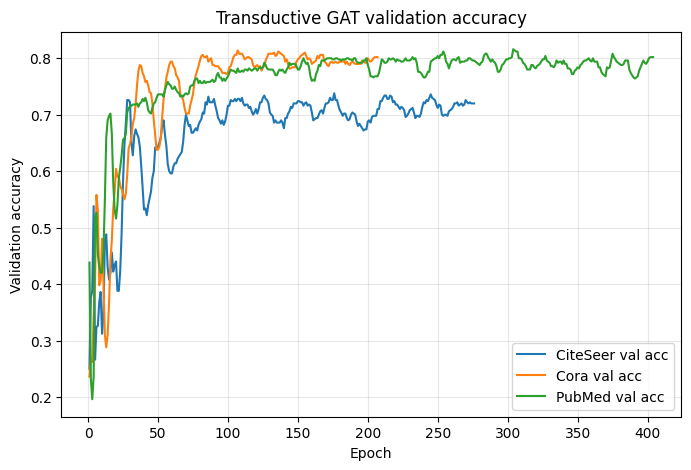

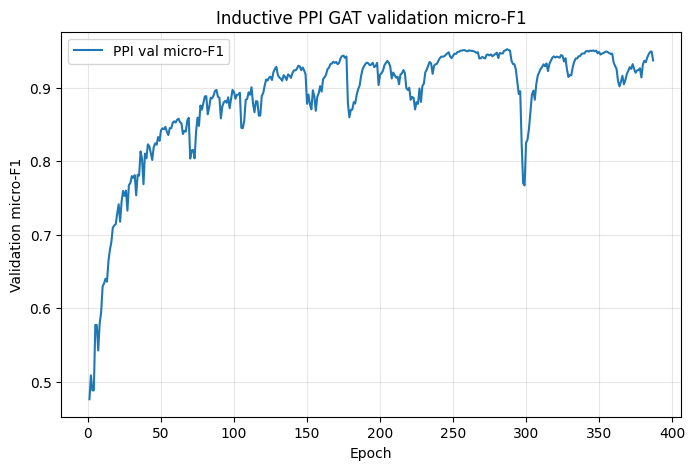

In [31]:
# ============================================================
# 11. Plot learning curves
# ============================================================

# Transductive validation accuracy curves
plt.figure(figsize=(8, 5))
for dataset_name, group in transductive_history_df.groupby('dataset'):
    plt.plot(group['epoch'], group['val_acc'], label=f'{dataset_name} val acc')
plt.xlabel('Epoch')
plt.ylabel('Validation accuracy')
plt.title('Transductive GAT validation accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# PPI validation micro-F1 curve
if RUN_PPI and not ppi_history_df.empty:
    plt.figure(figsize=(8, 5))
    plt.plot(ppi_history_df['epoch'], ppi_history_df['val_micro_f1'], label='PPI val micro-F1')
    plt.xlabel('Epoch')
    plt.ylabel('Validation micro-F1')
    plt.title('Inductive PPI GAT validation micro-F1')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


,dataset,setting,metric,score,paper_target_approx
0,Cora,transductive,test accuracy,0.820000,0.830
1,CiteSeer,transductive,test accuracy,0.718000,0.725
2,PubMed,transductive,test accuracy,0.777000,0.790
3,PPI,inductive,test micro-F1,0.969972,0.973


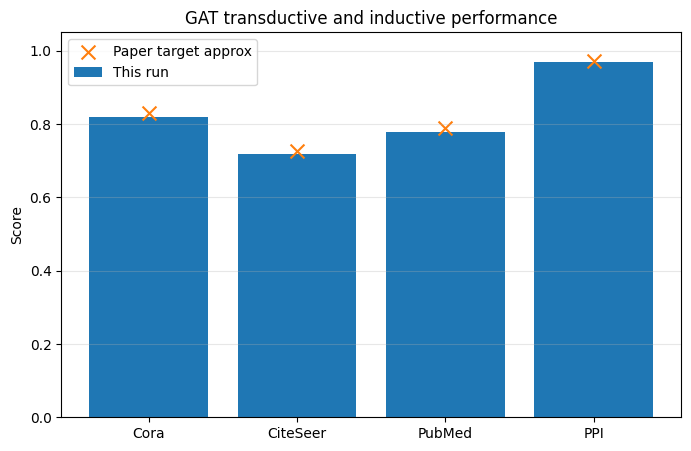

In [32]:
# ============================================================
# 12. Final comparison table + bar chart
# ============================================================

summary_rows = []
for row in transductive_results:
    summary_rows.append({
        'dataset': row['dataset'],
        'setting': 'transductive',
        'metric': 'test accuracy',
        'score': row['test_acc'],
        'paper_target_approx': {'Cora': 0.83, 'CiteSeer': 0.725, 'PubMed': 0.79}.get(row['dataset'], np.nan),
    })

if RUN_PPI and ppi_result is not None:
    summary_rows.append({
        'dataset': 'PPI',
        'setting': 'inductive',
        'metric': 'test micro-F1',
        'score': ppi_result['test_micro_f1'],
        'paper_target_approx': 0.973,
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

plt.figure(figsize=(8, 5))
plt.bar(summary_df['dataset'], summary_df['score'], label='This run')
plt.scatter(summary_df['dataset'], summary_df['paper_target_approx'], marker='x', s=100, label='Paper target approx')
plt.ylim(0, 1.05)
plt.ylabel('Score')
plt.title('GAT transductive and inductive performance')
plt.legend()
plt.grid(True, axis='y', alpha=0.3)
plt.show()


## Notes for interpreting results

Expected paper-style target ranges:

| Dataset | Setting | Metric | Approx. target |
|---|---:|---:|---:|
| Cora | transductive | accuracy | ~0.83 |
| CiteSeer | transductive | accuracy | ~0.72 |
| PubMed | transductive | accuracy | ~0.79 |
| PPI | inductive | micro-F1 | ~0.973 |


## Experiment 2: Deeper GAT (4 Layers)

Stack 4 total GAT layers (3 hidden + 1 output). Residual connections are enabled to support gradient flow through the deeper network.

In [8]:
# Install required packages
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
                       'torch-geometric', 'scikit-learn'])

0

In [9]:
# ============================================================
# Standalone setup — run this first if skipping cells 1-13
# ============================================================

import sys, os, shutil, gc, random, importlib
from pathlib import Path

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    # ── Colab: mount Drive and symlink models ─────────────────
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_DIR = Path('/content/drive/MyDrive/GAT/CS4782FinalProjectGraphAttention')
    RUNTIME_IMPORT_ROOT = Path('/content/gat_runtime_imports')
    RUNTIME_IMPORT_ROOT.mkdir(exist_ok=True)
    for link_name, src in [('models', PROJECT_DIR / 'models'),
                            ('utils',  PROJECT_DIR / 'utils')]:
        dst = RUNTIME_IMPORT_ROOT / link_name
        if dst.exists() or dst.is_symlink():
            dst.unlink() if (dst.is_symlink() or dst.is_file()) else shutil.rmtree(dst)
        os.symlink(src, dst)
    for p in [str(RUNTIME_IMPORT_ROOT), str(PROJECT_DIR)]:
        if p not in sys.path:
            sys.path.insert(0, p)
else:
    # ── Local: find the project root by searching for models/ + utils/ ─
    _cwd = Path(os.getcwd())
    # VS Code Jupyter injects __vsc_ipynb_file__ into kernel globals
    _nb_path = globals().get('__vsc_ipynb_file__', '')
    _candidates = []
    if _nb_path:
        # notebook lives at .../reimplementation/notebook.ipynb → project root is parent.parent
        _candidates.append(Path(_nb_path).parent.parent)
    _candidates += [
        _cwd / 'CS4782FinalProjectGraphAttention',         # cwd is outer GAT workspace dir
        _cwd.parent / 'CS4782FinalProjectGraphAttention',  # cwd is reimplementation/
        _cwd,
        _cwd.parent,
    ]
    PROJECT_DIR = next(
        (p for p in _candidates if (p / 'models').exists() and (p / 'utils').exists()),
        None
    )
    if PROJECT_DIR is None:
        raise RuntimeError(
            f'Cannot find project root from cwd={_cwd}.\n'
            'Set PROJECT_DIR manually at the top of this cell.')
    if str(PROJECT_DIR) not in sys.path:
        sys.path.insert(0, str(PROJECT_DIR))

# Clear stale module cache AND path-finder cache.
# importlib.invalidate_caches() flushes sys.path_importer_cache (FileFinder directory
# scan cache) so newly created symlinks / newly added sys.path entries are visible.
for _mod in list(sys.modules.keys()):
    if _mod == 'models' or _mod.startswith('models.') \
            or _mod == 'utils' or _mod.startswith('utils.'):
        del sys.modules[_mod]
importlib.invalidate_caches()

print('PROJECT_DIR =', PROJECT_DIR)

# ── Imports ───────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F
from torch_geometric.datasets import Planetoid, PPI
from torch_geometric.utils import add_self_loops
from torch_geometric.loader import DataLoader
from sklearn.metrics import f1_score

from models.gat import GAT
from models.sp_gat import SpGAT

# ── Device / seed / config ────────────────────────────────────
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device =', device)
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

os.environ.setdefault('PYTORCH_CUDA_ALLOC_CONF', 'expandable_segments:True')

DATA_ROOT = PROJECT_DIR / 'data'
print('DATA_ROOT =', DATA_ROOT, '| exists:', DATA_ROOT.exists())

RUN_TRANSDUCTIVE_DATASETS = ['Cora', 'CiteSeer', 'PubMed']
TRANSDUCTIVE_EPOCHS   = 10000
TRANSDUCTIVE_PATIENCE = 100
PPI_EPOCHS   = 10000
PPI_PATIENCE = 100

# ── Helper functions ──────────────────────────────────────────
def cleanup_cuda():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()

def preprocess_features(x):
    rowsum = x.sum(dim=1, keepdim=True).clamp(min=1e-9)
    return x / rowsum

def load_planetoid_dataset(name):
    dataset = Planetoid(root=str(DATA_ROOT), name=name)
    data = dataset[0]
    data.edge_index, _ = add_self_loops(data.edge_index, num_nodes=data.num_nodes)
    data.x = preprocess_features(data.x)
    return dataset, data

def edge_index_to_bias(edge_index, num_nodes, device):
    bias = torch.full((1, num_nodes, num_nodes), -1e9, device=device)
    edge_index = edge_index.to(device)
    bias[0, edge_index[0], edge_index[1]] = 0.0
    return bias

def edge_index_to_sparse_adj(edge_index, num_nodes, device):
    edge_index = edge_index.to(device)
    values = torch.ones(edge_index.shape[1], device=device)
    return torch.sparse_coo_tensor(
        edge_index, values, (num_nodes, num_nodes), device=device).coalesce()

def accuracy_from_logits(logits, y):
    return (logits.argmax(dim=-1) == y).float().mean().item()

def make_transductive_model(dataset, data, cfg):
    if cfg['use_sparse']:
        return SpGAT(
            in_features=dataset.num_features, nb_classes=dataset.num_classes,
            nb_nodes=data.num_nodes, hid_units=cfg['hid_units'], n_heads=cfg['n_heads'],
            attn_drop=cfg['attn_drop'], ffd_drop=cfg['ffd_drop'], residual=cfg['residual'],
        ).to(device)
    return GAT(
        in_features=dataset.num_features, nb_classes=dataset.num_classes,
        hid_units=cfg['hid_units'], n_heads=cfg['n_heads'],
        attn_drop=cfg['attn_drop'], ffd_drop=cfg['ffd_drop'], residual=cfg['residual'],
    ).to(device)

def forward_transductive(model, data, cfg):
    x = data.x.to(device).unsqueeze(0)
    if cfg['use_sparse']:
        adj = edge_index_to_sparse_adj(data.edge_index, data.num_nodes, device)
        return model(x, adj).squeeze(0)
    bias = edge_index_to_bias(data.edge_index, data.num_nodes, device)
    return model(x, bias).squeeze(0)

def evaluate_transductive(model, data, cfg, mask):
    model.eval()
    with torch.no_grad():
        logits = forward_transductive(model, data, cfg)
        y = data.y.to(device)
        mask = mask.to(device)
        loss = F.cross_entropy(logits[mask], y[mask]).item()
        acc = accuracy_from_logits(logits[mask], y[mask])
    return loss, acc

def make_ppi_model(sample, cfg):
    nb_classes = sample.y.shape[-1]
    if cfg['use_sparse']:
        return SpGAT(
            in_features=sample.num_node_features, nb_classes=nb_classes,
            nb_nodes=sample.num_nodes, hid_units=cfg['hid_units'], n_heads=cfg['n_heads'],
            attn_drop=cfg['attn_drop'], ffd_drop=cfg['ffd_drop'], residual=cfg['residual'],
        ).to(device)
    return GAT(
        in_features=sample.num_node_features, nb_classes=nb_classes,
        hid_units=cfg['hid_units'], n_heads=cfg['n_heads'],
        attn_drop=cfg['attn_drop'], ffd_drop=cfg['ffd_drop'], residual=cfg['residual'],
    ).to(device)

def forward_ppi(model, batch, cfg):
    batch = batch.to(device)
    x = batch.x.unsqueeze(0)
    N = batch.num_nodes
    if cfg['use_sparse']:
        model.nb_nodes = N
        adj = edge_index_to_sparse_adj(batch.edge_index, N, device)
        return model(x, adj).squeeze(0)
    bias = edge_index_to_bias(batch.edge_index, N, device)
    return model(x, bias).squeeze(0)

def ppi_micro_f1_from_logits(logits_list, labels_list):
    logits = torch.cat(logits_list, dim=0)
    labels = torch.cat(labels_list, dim=0)
    preds = (torch.sigmoid(logits) > 0.5).int().cpu().numpy()
    gold  = labels.int().cpu().numpy()
    return f1_score(gold, preds, average='micro')

def evaluate_ppi(model, loader, cfg):
    model.eval()
    losses, logits_list, labels_list = [], [], []
    criterion = torch.nn.BCEWithLogitsLoss()
    with torch.no_grad():
        for batch in loader:
            logits = forward_ppi(model, batch, cfg)
            labels = batch.y.to(device).float()
            losses.append(criterion(logits, labels).item())
            logits_list.append(logits.detach().cpu())
            labels_list.append(labels.detach().cpu())
    return float(np.mean(losses)), ppi_micro_f1_from_logits(logits_list, labels_list)

print('Setup complete.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PROJECT_DIR = /content/drive/MyDrive/GAT/CS4782FinalProjectGraphAttention
device = cuda
NVIDIA L4
DATA_ROOT = /content/drive/MyDrive/GAT/CS4782FinalProjectGraphAttention/data | exists: True
Setup complete.


In [10]:
# ============================================================
# 14. Helpers shared by both new experiments
# ============================================================

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def train_transductive_with_cfg(dataset_name, cfg, print_every=0):
    """Like train_transductive_dataset but accepts an explicit cfg dict."""
    cleanup_cuda()
    dataset, data = load_planetoid_dataset(dataset_name)
    model = make_transductive_model(dataset, data, cfg)
    optimizer = torch.optim.Adam(model.parameters(),
                                 lr=cfg['lr'], weight_decay=cfg['weight_decay'])

    y = data.y.to(device)
    train_mask = data.train_mask.to(device)
    best_val_acc = -1.0
    best_state = None
    patience = 0
    history = []

    for epoch in range(1, TRANSDUCTIVE_EPOCHS + 1):
        model.train()
        optimizer.zero_grad()
        logits = forward_transductive(model, data, cfg)
        loss = F.cross_entropy(logits[train_mask], y[train_mask])
        loss.backward()
        optimizer.step()

        train_loss, _ = evaluate_transductive(model, data, cfg, data.train_mask)
        val_loss, val_acc = evaluate_transductive(model, data, cfg, data.val_mask)
        _, test_acc = evaluate_transductive(model, data, cfg, data.test_mask)

        history.append(dict(dataset=dataset_name, epoch=epoch,
                            train_loss=train_loss, val_acc=val_acc, test_acc=test_acc))

        if print_every and (epoch == 1 or epoch % print_every == 0):
            print(f'{dataset_name:8s} | epoch {epoch:04d} | loss {train_loss:.4f} '
                  f'| val_acc {val_acc:.4f} | test_acc {test_acc:.4f}')

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience = 0
        else:
            patience += 1

        if patience >= TRANSDUCTIVE_PATIENCE:
            print(f'{dataset_name}: early stopping at epoch {epoch}')
            break

    if best_state is not None:
        model.load_state_dict({k: v.to(device) for k, v in best_state.items()})

    _, final_val_acc  = evaluate_transductive(model, data, cfg, data.val_mask)
    _, final_test_acc = evaluate_transductive(model, data, cfg, data.test_mask)
    print(f'FINAL {dataset_name}: val_acc={final_val_acc:.4f}, test_acc={final_test_acc:.4f}')
    cleanup_cuda()
    return pd.DataFrame(history), dict(dataset=dataset_name,
                                       val_acc=final_val_acc, test_acc=final_test_acc)


def train_ppi_with_cfg(cfg, print_every=0):
    """Like train_ppi_fullpaper but accepts an explicit cfg dict."""
    cleanup_cuda()
    ppi_train_ds = PPI(root=str(DATA_ROOT / 'PPI'), split='train')
    ppi_val_ds   = PPI(root=str(DATA_ROOT / 'PPI'), split='val')
    ppi_test_ds  = PPI(root=str(DATA_ROOT / 'PPI'), split='test')

    train_loader = DataLoader(ppi_train_ds, batch_size=cfg['batch_size'], shuffle=True)
    val_loader   = DataLoader(ppi_val_ds,   batch_size=1, shuffle=False)
    test_loader  = DataLoader(ppi_test_ds,  batch_size=1, shuffle=False)

    model = make_ppi_model(ppi_train_ds[0], cfg)
    optimizer = torch.optim.Adam(model.parameters(),
                                 lr=cfg['lr'], weight_decay=cfg['weight_decay'])
    criterion = torch.nn.BCEWithLogitsLoss()

    best_val_f1 = -1.0
    best_state = None
    patience = 0
    history = []

    for epoch in range(1, PPI_EPOCHS + 1):
        model.train()
        batch_losses = []
        for batch in train_loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            logits = forward_ppi(model, batch, cfg)
            loss = criterion(logits, batch.y.float())
            loss.backward()
            optimizer.step()
            batch_losses.append(loss.item())

        train_loss = float(np.mean(batch_losses))
        _, val_f1 = evaluate_ppi(model, val_loader, cfg)
        history.append(dict(epoch=epoch, train_loss=train_loss, val_micro_f1=val_f1))

        if print_every and (epoch == 1 or epoch % print_every == 0):
            print(f'PPI | epoch {epoch:04d} | train_loss {train_loss:.4f} | val_f1 {val_f1:.4f}')

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience = 0
        else:
            patience += 1

        if patience >= PPI_PATIENCE:
            print(f'PPI: early stopping at epoch {epoch}')
            break

    if best_state is not None:
        model.load_state_dict({k: v.to(device) for k, v in best_state.items()})

    _, test_f1 = evaluate_ppi(model, test_loader, cfg)
    print(f'FINAL PPI: val_micro_f1={best_val_f1:.4f}, test_micro_f1={test_f1:.4f}')
    cleanup_cuda()
    return pd.DataFrame(history), dict(dataset='PPI',
                                       val_micro_f1=best_val_f1, test_micro_f1=test_f1)

Architecture: `hid_units=[8, 8, 8]`, `n_heads=[8, 8, 8, 1]` for transductive (4 total layers); `hid_units=[256, 256, 256]`, `n_heads=[4, 4, 4, 6]` for PPI (4 total layers). All other hyperparameters match the original paper configs.

In [11]:
# ============================================================
# 18. 4-layer GAT configs (3 hidden + 1 output)
# ============================================================
# Transductive baseline: hid_units=[8],       n_heads=[8, 1]      (2 layers total)
# PPI baseline:          hid_units=[256, 256], n_heads=[4, 4, 6]   (3 layers total)

TRANSDUCTIVE_CONFIGS_4L = {
    'Cora':     dict(hid_units=[8, 8, 8], n_heads=[8, 8, 8, 1],
                     attn_drop=0.6, ffd_drop=0.6, lr=0.005, weight_decay=5e-4,
                     residual=True, use_sparse=False),
    'CiteSeer': dict(hid_units=[8, 8, 8], n_heads=[8, 8, 8, 1],
                     attn_drop=0.6, ffd_drop=0.6, lr=0.005, weight_decay=5e-4,
                     residual=True, use_sparse=False),
    'PubMed':   dict(hid_units=[8, 8, 8], n_heads=[8, 8, 8, 1],
                     attn_drop=0.6, ffd_drop=0.6, lr=0.005, weight_decay=1e-3,
                     residual=True, use_sparse=True),
}

PPI_CONFIG_4L = dict(
    hid_units=[256, 256, 256],
    n_heads=[4, 4, 4, 6],
    attn_drop=0.0,
    ffd_drop=0.0,
    lr=0.005,
    weight_decay=0.0,
    residual=True,
    use_sparse=True,
    batch_size=1,
)

SEEDS = [42, 123, 2024]

for name, cfg in TRANSDUCTIVE_CONFIGS_4L.items():
    print(f'{name}: {len(cfg["hid_units"]) + 1} total layers, '
          f'hid_units={cfg["hid_units"]}, n_heads={cfg["n_heads"]}')
print(f'PPI:  {len(PPI_CONFIG_4L["hid_units"]) + 1} total layers, '
      f'hid_units={PPI_CONFIG_4L["hid_units"]}, n_heads={PPI_CONFIG_4L["n_heads"]}')
print(f'Seeds: {SEEDS}')


Cora: 4 total layers, hid_units=[8, 8, 8], n_heads=[8, 8, 8, 1]
CiteSeer: 4 total layers, hid_units=[8, 8, 8], n_heads=[8, 8, 8, 1]
PubMed: 4 total layers, hid_units=[8, 8, 8], n_heads=[8, 8, 8, 1]
PPI:  4 total layers, hid_units=[256, 256, 256], n_heads=[4, 4, 4, 6]
Seeds: [42, 123, 2024]


In [12]:
# ============================================================
# 19. 4-layer: run transductive datasets (multiple seeds)
# ============================================================

all_seed_trans_results = []   # one entry per (seed, dataset)
repr_trans_hist = {}          # history from first seed, for plotting

for seed in SEEDS:
    set_seed(seed)
    print(f'\n=== Seed {seed} ===')
    for name in RUN_TRANSDUCTIVE_DATASETS:
        print(f'\n--- {name} (4-layer, seed={seed}) ---')
        hist, result = train_transductive_with_cfg(
            name, TRANSDUCTIVE_CONFIGS_4L[name], print_every=25)
        result['seed'] = seed
        all_seed_trans_results.append(result)
        if seed == SEEDS[0]:
            repr_trans_hist[name] = hist

# Summary: mean ± std of test_acc across seeds per dataset
trans_seed_df = pd.DataFrame(all_seed_trans_results)
deeper_trans_res_df = (
    trans_seed_df.groupby('dataset')['test_acc']
    .agg(mean_test_acc='mean', std_test_acc='std')
    .reset_index()
)
deeper_trans_hist_df = pd.concat(repr_trans_hist.values(), ignore_index=True)

print('\n=== 4-layer transductive results (mean ± std over seeds) ===')
display(deeper_trans_res_df)



=== Seed 42 ===

--- Cora (4-layer, seed=42) ---
Cora     | epoch 0001 | loss 1.9456 | val_acc 0.0720 | test_acc 0.0920
Cora     | epoch 0025 | loss 1.9299 | val_acc 0.2080 | test_acc 0.2000
Cora     | epoch 0050 | loss 1.6387 | val_acc 0.4740 | test_acc 0.4610
Cora     | epoch 0075 | loss 0.7280 | val_acc 0.7460 | test_acc 0.7560
Cora     | epoch 0100 | loss 0.5125 | val_acc 0.6960 | test_acc 0.7040
Cora     | epoch 0125 | loss 0.3248 | val_acc 0.7540 | test_acc 0.7670
Cora     | epoch 0150 | loss 0.2158 | val_acc 0.7820 | test_acc 0.8000
Cora     | epoch 0175 | loss 0.1565 | val_acc 0.7980 | test_acc 0.8090
Cora     | epoch 0200 | loss 0.1333 | val_acc 0.7840 | test_acc 0.7900
Cora     | epoch 0225 | loss 0.0952 | val_acc 0.7800 | test_acc 0.7960
Cora     | epoch 0250 | loss 0.0933 | val_acc 0.7680 | test_acc 0.7990
Cora: early stopping at epoch 271
FINAL Cora: val_acc=0.8060, test_acc=0.8040

--- CiteSeer (4-layer, seed=42) ---
CiteSeer | epoch 0001 | loss 1.7917 | val_acc 0.1920 |

,dataset,mean_test_acc,std_test_acc
0,CiteSeer,0.691000,0.008544
1,Cora,0.807000,0.003606
2,PubMed,0.770333,0.003215


In [13]:
# ============================================================
# 20. 4-layer: PPI (multiple seeds)
# ============================================================

all_seed_ppi_results = []
deeper_ppi_hist = None

for seed in SEEDS:
    set_seed(seed)
    print(f'\n=== PPI (4-layer, seed={seed}) ===')
    hist, result = train_ppi_with_cfg(PPI_CONFIG_4L, print_every=10)
    result['seed'] = seed
    all_seed_ppi_results.append(result)
    if seed == SEEDS[0]:
        deeper_ppi_hist = hist

ppi_seed_df = pd.DataFrame(all_seed_ppi_results)
deeper_ppi_result = {
    'dataset': 'PPI',
    'mean_test_micro_f1': ppi_seed_df['test_micro_f1'].mean(),
    'std_test_micro_f1':  ppi_seed_df['test_micro_f1'].std(),
}

print('\n=== 4-layer PPI results (mean ± std over seeds) ===')
display(pd.DataFrame([deeper_ppi_result]))



=== PPI (4-layer, seed=42) ===
PPI | epoch 0001 | train_loss 1.2305 | val_f1 0.4260
PPI | epoch 0010 | train_loss 0.4999 | val_f1 0.5501
PPI | epoch 0020 | train_loss 0.4347 | val_f1 0.6341
PPI | epoch 0030 | train_loss 0.3238 | val_f1 0.7222
PPI | epoch 0040 | train_loss 0.2338 | val_f1 0.8048
PPI | epoch 0050 | train_loss 0.1910 | val_f1 0.8129
PPI | epoch 0060 | train_loss 0.1546 | val_f1 0.8628
PPI | epoch 0070 | train_loss 0.1326 | val_f1 0.8693
PPI | epoch 0080 | train_loss 0.1013 | val_f1 0.8898
PPI | epoch 0090 | train_loss 0.1332 | val_f1 0.8840
PPI | epoch 0100 | train_loss 0.1118 | val_f1 0.8775
PPI | epoch 0110 | train_loss 0.1328 | val_f1 0.8850
PPI | epoch 0120 | train_loss 0.1188 | val_f1 0.8873
PPI | epoch 0130 | train_loss 0.1532 | val_f1 0.8741
PPI | epoch 0140 | train_loss 0.1948 | val_f1 0.8235
PPI | epoch 0150 | train_loss 0.1095 | val_f1 0.9004
PPI | epoch 0160 | train_loss 0.1371 | val_f1 0.8826
PPI | epoch 0170 | train_loss 0.1883 | val_f1 0.8312
PPI | epoch 01

,dataset,mean_test_micro_f1,std_test_micro_f1
0,PPI,0.934504,0.00892


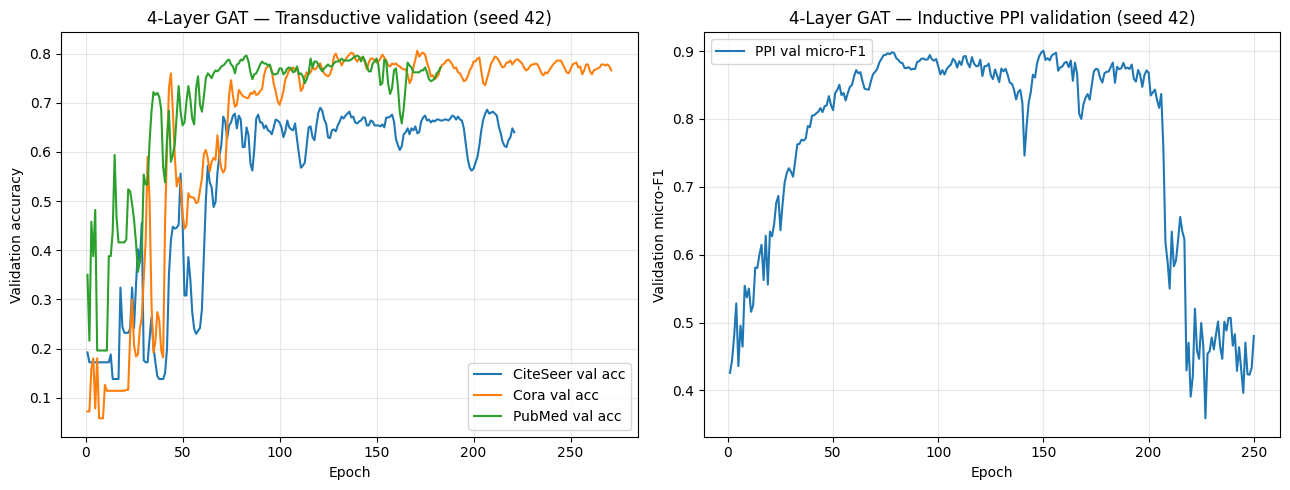

In [14]:
# ============================================================
# 21. 4-layer: validation curves (seed={SEEDS[0]})
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for name, grp in deeper_trans_hist_df.groupby('dataset'):
    axes[0].plot(grp['epoch'], grp['val_acc'], label=f'{name} val acc')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Validation accuracy')
axes[0].set_title(f'4-Layer GAT — Transductive validation (seed {SEEDS[0]})')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(deeper_ppi_hist['epoch'], deeper_ppi_hist['val_micro_f1'],
             label='PPI val micro-F1')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Validation micro-F1')
axes[1].set_title(f'4-Layer GAT — Inductive PPI validation (seed {SEEDS[0]})')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


---

## Experiment 3: Bug-Fixed GAT (`layers2.py`)

Fixes relative to Experiment 1:

1. **LeakyReLU slope**: `negative_slope=0.2` (matches TF default `alpha=0.2`; was 0.01 in `layers.py`)
2. **Xavier initialization**: W, a_1, a_2, res_proj use `xavier_uniform_` (matches TF `tf.layers.conv1d` default; bias of a_1/a_2 initialized to zero)
3. **Early stopping — patience**: resets on val_acc **or** val_loss improvement (original uses OR logic)
4. **Early stopping — save**: checkpoint saved only when val_acc **and** val_loss both improve simultaneously

Uses `models/gat2.py` and `models/sp_gat2.py`, which import from `utils/layers2.py`.

In [1]:
# ============================================================
# E3-0. Standalone setup — run this first if skipping Exp 1 & 2
# ============================================================

import sys, os, shutil, gc, random, importlib
from pathlib import Path

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_DIR = Path('/content/drive/MyDrive/GAT/CS4782FinalProjectGraphAttention')
    RUNTIME_IMPORT_ROOT = Path('/content/gat_runtime_imports')
    RUNTIME_IMPORT_ROOT.mkdir(exist_ok=True)
    for link_name, src in [('models', PROJECT_DIR / 'models'),
                            ('utils',  PROJECT_DIR / 'utils')]:
        dst = RUNTIME_IMPORT_ROOT / link_name
        if dst.exists() or dst.is_symlink():
            dst.unlink() if (dst.is_symlink() or dst.is_file()) else shutil.rmtree(dst)
        os.symlink(src, dst)
    for p in [str(RUNTIME_IMPORT_ROOT), str(PROJECT_DIR)]:
        if p not in sys.path:
            sys.path.insert(0, p)
else:
    _nb_path = globals().get('__vsc_ipynb_file__', '')
    _candidates = []
    if _nb_path:
        _candidates.append(Path(_nb_path).parent.parent)
    _cwd = Path(os.getcwd())
    _candidates += [
        _cwd / 'CS4782FinalProjectGraphAttention',
        _cwd.parent / 'CS4782FinalProjectGraphAttention',
        _cwd, _cwd.parent,
    ]
    PROJECT_DIR = next(
        (p for p in _candidates if (p / 'models').exists() and (p / 'utils').exists()), None)
    if PROJECT_DIR is None:
        raise RuntimeError('Cannot find project root. Set PROJECT_DIR manually.')
    if str(PROJECT_DIR) not in sys.path:
        sys.path.insert(0, str(PROJECT_DIR))

# Clear stale module cache so layers2 / gat2 / sp_gat2 are picked up fresh
for _mod in list(sys.modules.keys()):
    if _mod in ('models.gat2', 'models.sp_gat2', 'utils.layers2',
                'models.gat', 'models.sp_gat', 'utils.layers',
                'models', 'utils'):
        del sys.modules[_mod]
importlib.invalidate_caches()

print('PROJECT_DIR =', PROJECT_DIR)

# ── Library imports ───────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F
from torch_geometric.datasets import Planetoid, PPI
from torch_geometric.utils import add_self_loops
from torch_geometric.loader import DataLoader
from sklearn.metrics import f1_score

from models.gat2 import GAT as GAT2
from models.sp_gat2 import SpGAT as SpGAT2

# ── Device / seed ─────────────────────────────────────────────────────────────
SEED = 42

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device =', device)
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

os.environ.setdefault('PYTORCH_CUDA_ALLOC_CONF', 'expandable_segments:True')

# ── Paths and constants ───────────────────────────────────────────────────────
DATA_ROOT = PROJECT_DIR / 'data'
print('DATA_ROOT =', DATA_ROOT, '| exists:', DATA_ROOT.exists())

RUN_TRANSDUCTIVE_DATASETS = ['Cora', 'CiteSeer', 'PubMed']
TRANSDUCTIVE_EPOCHS   = 10000
TRANSDUCTIVE_PATIENCE = 100
PPI_EPOCHS   = 10000
PPI_PATIENCE = 100

# ── Helper functions ──────────────────────────────────────────────────────────
def cleanup_cuda():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()

def preprocess_features(x):
    rowsum = x.sum(dim=1, keepdim=True).clamp(min=1e-9)
    return x / rowsum

def load_planetoid_dataset(name):
    dataset = Planetoid(root=str(DATA_ROOT), name=name)
    data = dataset[0]
    data.edge_index, _ = add_self_loops(data.edge_index, num_nodes=data.num_nodes)
    data.x = preprocess_features(data.x)
    return dataset, data

def edge_index_to_bias(edge_index, num_nodes, device):
    bias = torch.full((1, num_nodes, num_nodes), -1e9, device=device)
    edge_index = edge_index.to(device)
    bias[0, edge_index[0], edge_index[1]] = 0.0
    return bias

def edge_index_to_sparse_adj(edge_index, num_nodes, device):
    edge_index = edge_index.to(device)
    values = torch.ones(edge_index.shape[1], device=device)
    return torch.sparse_coo_tensor(
        edge_index, values, (num_nodes, num_nodes), device=device).coalesce()

def accuracy_from_logits(logits, y):
    return (logits.argmax(dim=-1) == y).float().mean().item()

def forward_transductive(model, data, cfg):
    x = data.x.to(device).unsqueeze(0)
    if cfg['use_sparse']:
        adj = edge_index_to_sparse_adj(data.edge_index, data.num_nodes, device)
        return model(x, adj).squeeze(0)
    bias = edge_index_to_bias(data.edge_index, data.num_nodes, device)
    return model(x, bias).squeeze(0)

def evaluate_transductive(model, data, cfg, mask):
    model.eval()
    with torch.no_grad():
        logits = forward_transductive(model, data, cfg)
        y = data.y.to(device)
        mask = mask.to(device)
        loss = F.cross_entropy(logits[mask], y[mask]).item()
        acc  = accuracy_from_logits(logits[mask], y[mask])
    return loss, acc

def forward_ppi(model, batch, cfg):
    batch = batch.to(device)
    x = batch.x.unsqueeze(0)
    N = batch.num_nodes
    if cfg['use_sparse']:
        model.nb_nodes = N
        adj = edge_index_to_sparse_adj(batch.edge_index, N, device)
        return model(x, adj).squeeze(0)
    bias = edge_index_to_bias(batch.edge_index, N, device)
    return model(x, bias).squeeze(0)

def ppi_micro_f1_from_logits(logits_list, labels_list):
    logits = torch.cat(logits_list, dim=0)
    labels = torch.cat(labels_list, dim=0)
    preds  = (torch.sigmoid(logits) > 0.5).int().cpu().numpy()
    gold   = labels.int().cpu().numpy()
    return f1_score(gold, preds, average='micro')

def evaluate_ppi(model, loader, cfg):
    model.eval()
    losses, logits_list, labels_list = [], [], []
    criterion = torch.nn.BCEWithLogitsLoss()
    with torch.no_grad():
        for batch in loader:
            logits = forward_ppi(model, batch, cfg)
            labels = batch.y.to(device).float()
            losses.append(criterion(logits, labels).item())
            logits_list.append(logits.detach().cpu())
            labels_list.append(labels.detach().cpu())
    return float(np.mean(losses)), ppi_micro_f1_from_logits(logits_list, labels_list)

print('Setup complete. GAT2:', GAT2, '| SpGAT2:', SpGAT2)

NameError: name 'sys' is not defined

In [ ]:
# ============================================================
# E3-2. Configs (same hyperparameters as Experiment 1)
# ============================================================

EXP3_TRANSDUCTIVE_CONFIGS = {
    'Cora':     dict(hid_units=[8], n_heads=[8, 1], attn_drop=0.6, ffd_drop=0.6,
                     lr=0.005, weight_decay=5e-4, residual=False, use_sparse=False),
    'CiteSeer': dict(hid_units=[8], n_heads=[8, 1], attn_drop=0.6, ffd_drop=0.6,
                     lr=0.005, weight_decay=5e-4, residual=False, use_sparse=False),
    'PubMed':   dict(hid_units=[8], n_heads=[8, 1], attn_drop=0.6, ffd_drop=0.6,
                     lr=0.005, weight_decay=1e-3,  residual=False, use_sparse=True),
}

EXP3_PPI_CONFIG = dict(
    hid_units=[256, 256], n_heads=[4, 4, 6],
    attn_drop=0.0, ffd_drop=0.0, lr=0.005, weight_decay=0.0,
    residual=True, use_sparse=True, batch_size=1,
)

In [ ]:
# ============================================================
# E3-3. Model factory (uses GAT2 / SpGAT2)
# ============================================================

def make_transductive_model_v2(dataset, data, cfg):
    if cfg['use_sparse']:
        return SpGAT2(
            in_features=dataset.num_features, nb_classes=dataset.num_classes,
            nb_nodes=data.num_nodes, hid_units=cfg['hid_units'], n_heads=cfg['n_heads'],
            attn_drop=cfg['attn_drop'], ffd_drop=cfg['ffd_drop'], residual=cfg['residual'],
        ).to(device)
    return GAT2(
        in_features=dataset.num_features, nb_classes=dataset.num_classes,
        hid_units=cfg['hid_units'], n_heads=cfg['n_heads'],
        attn_drop=cfg['attn_drop'], ffd_drop=cfg['ffd_drop'], residual=cfg['residual'],
    ).to(device)

def make_ppi_model_v2(sample, cfg):
    nb_classes = sample.y.shape[-1]
    if cfg['use_sparse']:
        return SpGAT2(
            in_features=sample.num_node_features, nb_classes=nb_classes,
            nb_nodes=sample.num_nodes, hid_units=cfg['hid_units'], n_heads=cfg['n_heads'],
            attn_drop=cfg['attn_drop'], ffd_drop=cfg['ffd_drop'], residual=cfg['residual'],
        ).to(device)
    return GAT2(
        in_features=sample.num_node_features, nb_classes=nb_classes,
        hid_units=cfg['hid_units'], n_heads=cfg['n_heads'],
        attn_drop=cfg['attn_drop'], ffd_drop=cfg['ffd_drop'], residual=cfg['residual'],
    ).to(device)

In [ ]:
# ============================================================
# E3-4. Training functions with fixed early stopping
#        Patience resets on val_acc OR val_loss improvement.
#        Checkpoint saved only when BOTH improve simultaneously.
# ============================================================

def train_transductive_v2(dataset_name, cfg, print_every=25):
    cleanup_cuda()
    dataset, data = load_planetoid_dataset(dataset_name)
    model = make_transductive_model_v2(dataset, data, cfg)
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg['lr'], weight_decay=cfg['weight_decay'])

    y = data.y.to(device)
    train_mask = data.train_mask.to(device)

    best_val_acc  = -1.0
    best_val_loss = float('inf')
    best_state = None
    patience = 0
    history = []

    for epoch in range(1, TRANSDUCTIVE_EPOCHS + 1):
        model.train()
        optimizer.zero_grad()
        logits = forward_transductive(model, data, cfg)
        loss = F.cross_entropy(logits[train_mask], y[train_mask])
        loss.backward()
        optimizer.step()

        train_loss, train_acc = evaluate_transductive(model, data, cfg, data.train_mask)
        val_loss,   val_acc  = evaluate_transductive(model, data, cfg, data.val_mask)
        _,          test_acc = evaluate_transductive(model, data, cfg, data.test_mask)

        history.append(dict(dataset=dataset_name, epoch=epoch,
                            train_loss=train_loss, val_loss=val_loss,
                            val_acc=val_acc, test_acc=test_acc))

        if print_every and (epoch == 1 or epoch % print_every == 0):
            print(f'{dataset_name:8s} | epoch {epoch:04d} | loss {train_loss:.4f} '
                  f'| val_acc {val_acc:.4f} | test_acc {test_acc:.4f}')

        if val_acc >= best_val_acc or val_loss <= best_val_loss:
            patience = 0
            if val_acc >= best_val_acc and val_loss <= best_val_loss:
                best_val_acc  = val_acc
                best_val_loss = val_loss
                best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            else:
                if val_acc  >= best_val_acc:  best_val_acc  = val_acc
                if val_loss <= best_val_loss: best_val_loss = val_loss
        else:
            patience += 1

        if patience >= TRANSDUCTIVE_PATIENCE:
            print(f'{dataset_name}: early stopping at epoch {epoch}')
            break

    if best_state is not None:
        model.load_state_dict({k: v.to(device) for k, v in best_state.items()})

    _, final_val_acc  = evaluate_transductive(model, data, cfg, data.val_mask)
    _, final_test_acc = evaluate_transductive(model, data, cfg, data.test_mask)
    print(f'FINAL {dataset_name}: val_acc={final_val_acc:.4f}, test_acc={final_test_acc:.4f}')
    cleanup_cuda()
    return pd.DataFrame(history), dict(dataset=dataset_name,
                                       val_acc=final_val_acc, test_acc=final_test_acc)


def train_ppi_v2(cfg, print_every=10):
    cleanup_cuda()
    ppi_train_ds = PPI(root=str(DATA_ROOT / 'PPI'), split='train')
    ppi_val_ds   = PPI(root=str(DATA_ROOT / 'PPI'), split='val')
    ppi_test_ds  = PPI(root=str(DATA_ROOT / 'PPI'), split='test')

    train_loader = DataLoader(ppi_train_ds, batch_size=cfg['batch_size'], shuffle=True)
    val_loader   = DataLoader(ppi_val_ds,   batch_size=1, shuffle=False)
    test_loader  = DataLoader(ppi_test_ds,  batch_size=1, shuffle=False)

    model = make_ppi_model_v2(ppi_train_ds[0], cfg)
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg['lr'], weight_decay=cfg['weight_decay'])
    criterion = torch.nn.BCEWithLogitsLoss()

    best_val_f1   = -1.0
    best_val_loss = float('inf')
    best_state = None
    patience = 0
    history = []

    for epoch in range(1, PPI_EPOCHS + 1):
        model.train()
        batch_losses = []
        for batch in train_loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            logits = forward_ppi(model, batch, cfg)
            loss = criterion(logits, batch.y.float())
            loss.backward()
            optimizer.step()
            batch_losses.append(loss.item())

        train_loss = float(np.mean(batch_losses))
        val_loss, val_f1 = evaluate_ppi(model, val_loader, cfg)
        history.append(dict(epoch=epoch, train_loss=train_loss, val_loss=val_loss, val_micro_f1=val_f1))

        if print_every and (epoch == 1 or epoch % print_every == 0):
            print(f'PPI | epoch {epoch:04d} | train_loss {train_loss:.4f} | val_f1 {val_f1:.4f}')

        if val_f1 >= best_val_f1 or val_loss <= best_val_loss:
            patience = 0
            if val_f1 >= best_val_f1 and val_loss <= best_val_loss:
                best_val_f1   = val_f1
                best_val_loss = val_loss
                best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            else:
                if val_f1   >= best_val_f1:   best_val_f1   = val_f1
                if val_loss <= best_val_loss: best_val_loss = val_loss
        else:
            patience += 1

        if patience >= PPI_PATIENCE:
            print(f'PPI: early stopping at epoch {epoch}')
            break

    if best_state is not None:
        model.load_state_dict({k: v.to(device) for k, v in best_state.items()})

    _, test_f1 = evaluate_ppi(model, test_loader, cfg)
    print(f'FINAL PPI: val_micro_f1={best_val_f1:.4f}, test_micro_f1={test_f1:.4f}')
    cleanup_cuda()
    return pd.DataFrame(history), dict(dataset='PPI',
                                       val_micro_f1=best_val_f1, test_micro_f1=test_f1)

In [ ]:
# ============================================================
# E3-5. Run transductive experiments (Cora, CiteSeer, PubMed)
# ============================================================

set_seed(SEED)

exp3_trans_histories = []
exp3_trans_results   = []

for dataset_name in RUN_TRANSDUCTIVE_DATASETS:
    hist, result = train_transductive_v2(dataset_name, EXP3_TRANSDUCTIVE_CONFIGS[dataset_name])
    exp3_trans_histories.append(hist)
    exp3_trans_results.append(result)

exp3_trans_df = pd.DataFrame(exp3_trans_results)
display(exp3_trans_df)

In [ ]:
# ============================================================
# E3-6. Run PPI inductive experiment
# ============================================================

set_seed(SEED)

exp3_ppi_hist, exp3_ppi_result = train_ppi_v2(EXP3_PPI_CONFIG)
display(pd.DataFrame([exp3_ppi_result]))

In [ ]:
# ============================================================
# E3-7. Compare Experiment 3 vs Experiment 1 vs paper targets
# ============================================================

# Experiment 1 results (from earlier run, hardcoded for standalone use)
EXP1_RESULTS = {
    'Cora':     0.820,
    'CiteSeer': 0.718,
    'PubMed':   0.777,
    'PPI':      0.970,
}

paper_targets = {'Cora': 0.830, 'CiteSeer': 0.725, 'PubMed': 0.790, 'PPI': 0.973}

rows = []
for r in exp3_trans_results:
    d = r['dataset']
    rows.append({'dataset': d, 'Exp1 (original)': EXP1_RESULTS[d],
                 'Exp3 (bug-fixed)': r['test_acc'], 'Paper': paper_targets[d]})
rows.append({'dataset': 'PPI',
             'Exp1 (original)': EXP1_RESULTS['PPI'],
             'Exp3 (bug-fixed)': exp3_ppi_result['test_micro_f1'],
             'Paper': paper_targets['PPI']})

cmp_df = pd.DataFrame(rows).set_index('dataset')
display(cmp_df.round(4))

fig, ax = plt.subplots(figsize=(9, 5))
datasets = list(paper_targets.keys())
x = range(len(datasets))
w = 0.25
ax.bar([i - w for i in x], [cmp_df.loc[d, 'Exp1 (original)'] for d in datasets], w, label='Exp 1 (original)')
ax.bar([i      for i in x], [cmp_df.loc[d, 'Exp3 (bug-fixed)'] for d in datasets], w, label='Exp 3 (bug-fixed)')
ax.scatter(x, [paper_targets[d] for d in datasets], marker='x', s=120, zorder=5, label='Paper target')
ax.set_xticks(list(x)); ax.set_xticklabels(datasets)
ax.set_ylim(0, 1.05); ax.set_ylabel('Score')
ax.set_title('Experiment 1 vs Experiment 3 vs Paper')
ax.legend(); ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout(); plt.show()